In [1]:
import numpy as np
import matplotlib.pyplot as plt
from utils import annotated_heatmap, analytical_policy_evaluation, epsilon_greedy_policy
from environments import CorridorEnvTerminalReward

In [5]:
env = CorridorEnvTerminalReward(n_states=10, is_slippery=False)

n_states = env.nS
n_actions = env.nA

possible_actions = np.linspace(0, env.nA-1, env.nA)

In [9]:
def q_learning(epsilon: float = 0.1, alpha: float = 0.9, gamma: float = 1.0, num_episodes: int = 10):

    # Similarly for the q-table to be safe using list comprehension because list is mutable
    q = [[0.0 for _ in range(n_actions)] for _ in range(n_states)]

    v = [0.0]*n_states # this can be defined using "*" instead of list comprehension because int is immutable
    
    err = []
    optimal_pi = [[0, 0, 1]]*n_states
    v_analytical = analytical_policy_evaluation(optimal_pi, env.model, gamma=gamma)
    
    for e in range(num_episodes):
        done = False
        s = np.random.randint(0,env.nS)
        G = 0
        while not done:
            a = epsilon_greedy_policy(q[s], epsilon = epsilon)
            [_, s_, r, done] = env.step(s, a)[0]
            target = max(q[s_])*gamma*(not done) + r
            error = target - q[s][a]
            q[s][a] += alpha * error
            v[s] = max(q[s])
            s = s_
        err.append(sum((v_analytical - v)**2)/n_states)
    return v, err

In [29]:
num_trials = 20  # More trials = smoother confidence interval
num_episodes = 250
all_errors = []

for i in range(num_trials):
    # Keep epsilon constant to see the behavior of a specific setting
    _, ql_err = q_learning(epsilon=0.1, alpha=0.15, gamma=0.95, num_episodes=num_episodes)
    all_errors.append(ql_err)

# Convert to a numpy array for easy math: shape (20, 250)
all_errors = np.array(all_errors)

mean_err = np.mean(all_errors, axis=0)
std_err = np.std(all_errors, axis=0)

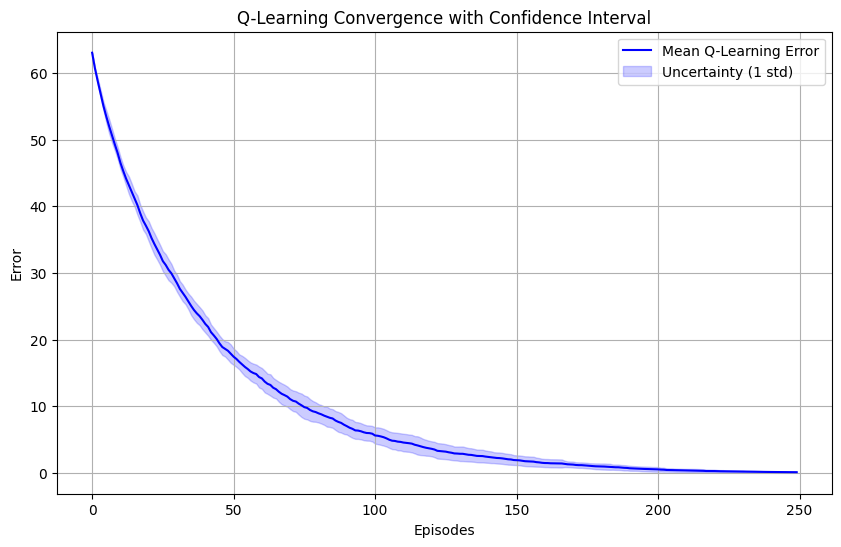

In [30]:
episodes = np.arange(num_episodes)

plt.figure(figsize=(10, 6))
plt.plot(episodes, mean_err, label="Mean Q-Learning Error", color='blue')

# Create the shaded confidence interval (Mean +/- 1 Standard Deviation)
plt.fill_between(episodes, 
                 mean_err - std_err, 
                 mean_err + std_err, 
                 color='blue', alpha=0.2, label="Uncertainty (1 std)")

plt.xlabel("Episodes")
plt.ylabel("Error")
plt.title("Q-Learning Convergence with Confidence Interval")
plt.legend()
plt.grid(True)
plt.show()

In [31]:
def double_q_learning(epsilon: float = 0.1, alpha: float = 0.9, gamma: float = 1.0, num_episodes: int = 10):

    # Similarly for the q-table to be safe using list comprehension because list is mutable
    q1 = [[0.0 for _ in range(n_actions)] for _ in range(n_states)]
    q2 = [[0.0 for _ in range(n_actions)] for _ in range(n_states)]

    v = [0.0]*n_states # this can be defined using "*" instead of list comprehension because int is immutable
    
    err = []
    optimal_pi = [[0, 0, 1]]*n_states
    v_analytical = analytical_policy_evaluation(optimal_pi, env.model, gamma=gamma)
    
    for e in range(num_episodes):
        done = False
        s = np.random.randint(0,env.nS)
        G = 0
        while not done:
            q_sum = np.array(q1[s]) + np.array(q2[s])
            a = epsilon_greedy_policy(q_sum, epsilon = epsilon)
            [_, s_, r, done] = env.step(s, a)[0]
            q = q1 if np.random.rand() < 0.5 else q2
            target = max(q[s_])*gamma*(not done) + r
            error = target - q[s][a]
            q[s][a] += alpha * error
            v[s] = max(q[s])
            s = s_
        err.append(sum((v_analytical - v)**2)/n_states)
    return v, err

In [35]:
num_trials = 20  # More trials = smoother confidence interval
num_episodes = 250
all_errors = []

for i in range(num_trials):
    # Keep epsilon constant to see the behavior of a specific setting
    _, ql_err = double_q_learning(epsilon=0.1, alpha=0.15, gamma=0.95, num_episodes=num_episodes)
    all_errors.append(ql_err)

# Convert to a numpy array for easy math: shape (20, 250)
all_errors = np.array(all_errors)

mean_err = np.mean(all_errors, axis=0)
std_err = np.std(all_errors, axis=0)

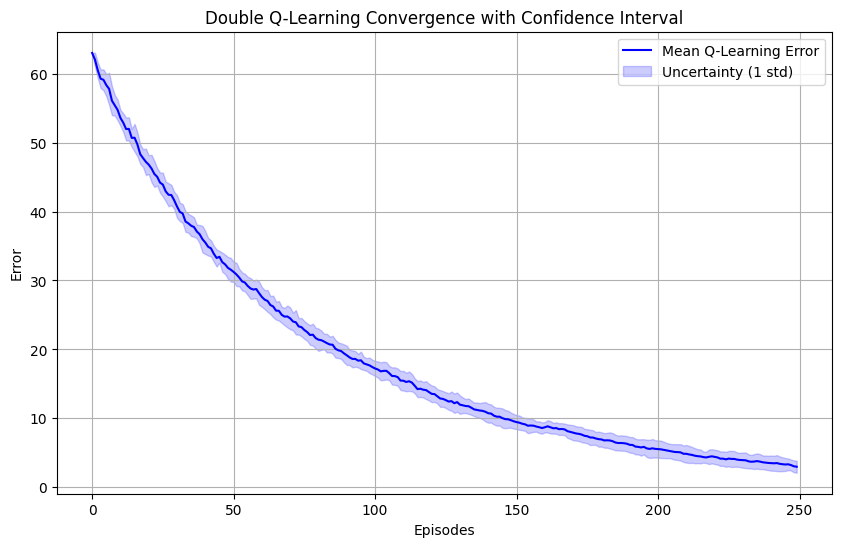

In [37]:
episodes = np.arange(num_episodes)

plt.figure(figsize=(10, 6))
plt.plot(episodes, mean_err, label="Mean Q-Learning Error", color='blue')

# Create the shaded confidence interval (Mean +/- 1 Standard Deviation)
plt.fill_between(episodes, 
                 mean_err - std_err, 
                 mean_err + std_err, 
                 color='blue', alpha=0.2, label="Uncertainty (1 std)")

plt.xlabel("Episodes")
plt.ylabel("Error")
plt.title("Double Q-Learning Convergence with Confidence Interval")
plt.legend()
plt.grid(True)
plt.show()